正在加载数据集: MNIST ...
开始训练 | 设备: cuda
Epoch: 1/2 | Batch: 100 | Loss: 2.3045 | Acc: 10.16%
Epoch: 1/2 | Batch: 200 | Loss: 0.2100 | Acc: 95.31%
Epoch: 2/2 | Batch: 100 | Loss: 0.0660 | Acc: 98.05%
Epoch: 2/2 | Batch: 200 | Loss: 0.1234 | Acc: 96.48%
准备固定测试子集用于评估功能连接...
开始演化分析... 总步数: 470, 采样间隔: 10


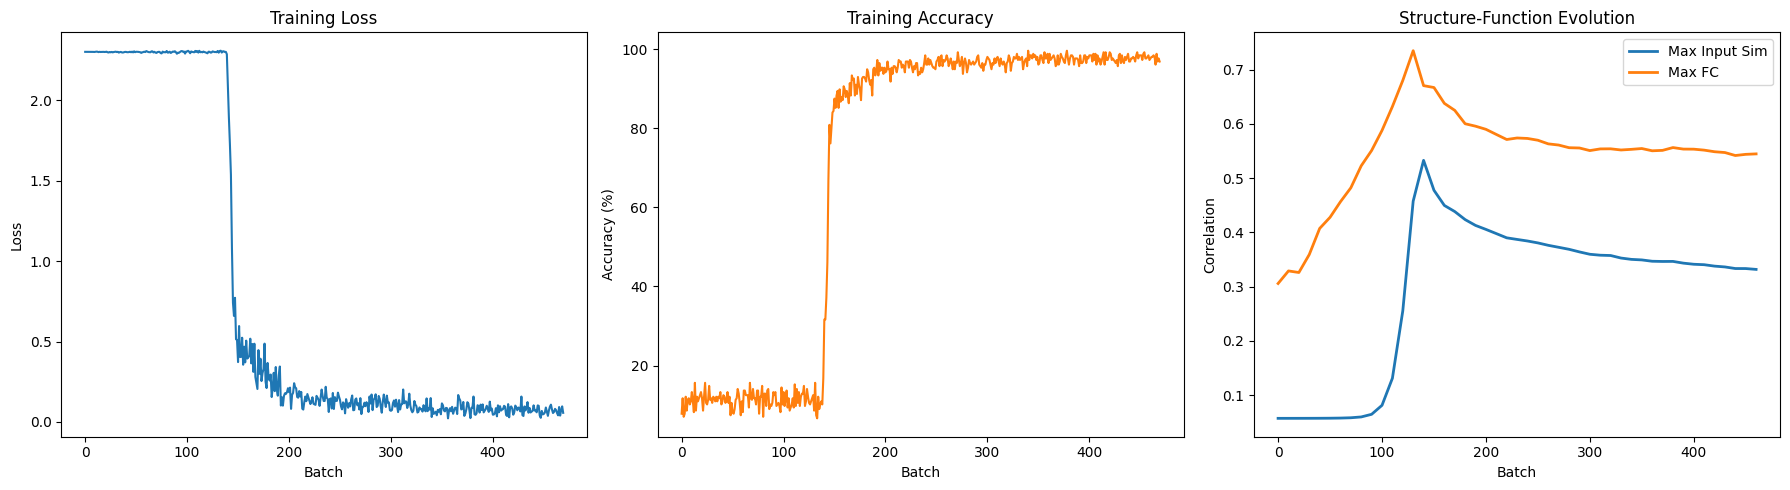

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import random
import warnings

warnings.filterwarnings('ignore')

# ==================== 1. 设置随机种子 ====================
def set_seed(seed=42):
    random.seed(seed)                
    np.random.seed(seed)          
    torch.manual_seed(seed)        
    torch.cuda.manual_seed(seed)    
    torch.cuda.manual_seed_all(seed)  
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark = False   

# ==================== 2. 多数据集统一加载模块 ====================
def load_dataset(dataset_name='CIFAR10', batch_size=128):
    """
    统一将所有图像处理为 32x32 尺寸，以对齐网络中后期的特征图维度
    """
    print(f"正在加载数据集: {dataset_name} ...")
    if dataset_name == 'MNIST':
        transform = transforms.Compose([
            transforms.Resize((32, 32)),  # 缩放到 32x32
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])
        train_dataset = datasets.MNIST('./data', train=True, transform=transform, download=True)
        test_dataset = datasets.MNIST('./data', train=False, transform=transform, download=True)
        in_channels = 1
        
    elif dataset_name == 'FashionMNIST':
        transform = transforms.Compose([
            transforms.Resize((32, 32)),  # 缩放到 32x32
            transforms.ToTensor(),
            transforms.Normalize((0.2860,), (0.3530,))
        ])
        train_dataset = datasets.FashionMNIST('./data', train=True, transform=transform, download=True)
        test_dataset = datasets.FashionMNIST('./data', train=False, transform=transform, download=True)
        in_channels = 1
        
    elif dataset_name == 'CIFAR10':
        transform = transforms.Compose([
            transforms.ToTensor(), # CIFAR10 原生就是 32x32
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
        ])
        train_dataset = datasets.CIFAR10('./data', train=True, transform=transform, download=True)
        test_dataset = datasets.CIFAR10('./data', train=False, transform=transform, download=True)
        in_channels = 3
    else:
        raise ValueError("不支持的数据集。请选择 'MNIST', 'FashionMNIST' 或 'CIFAR10'")

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader, in_channels

def get_fixed_subset(data_loader, samples_per_class=30):
    """提取固定数据子集用于计算FC，保证每次评估的数据基准一致"""
    class_samples = {i: [] for i in range(10)}
    for data, targets in data_loader:
        for i in range(len(targets)):
            label = targets[i].item()
            if len(class_samples[label]) < samples_per_class:
                class_samples[label].append(data[i])
        if all(len(samples) >= samples_per_class for samples in class_samples.values()):
            break
            
    all_samples = []
    for label in range(10):
        all_samples.extend(class_samples[label])
    return torch.stack(all_samples)

# ==================== 3. CNN 模型定义 (自适应 32x32) ====================
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=1, activation='relu', init_method='kaiming'):
        super(SimpleCNN, self).__init__()
        # Layer 1: 输入 [B, C, 32, 32] -> Conv -> [B, 32, 28, 28] -> Pool -> [B, 32, 14, 14]
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=5, padding=0)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Layer 2: 输入 [B, 32, 14, 14] -> Conv -> [B, 64, 10, 10] -> Pool -> [B, 64, 5, 5]
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=0)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Output: 64 * 5 * 5 = 1600 个特征
        self.fc = nn.Linear(64 * 5 * 5, 10)
        
        # 激活函数
        if activation == 'relu': self.act = nn.ReLU()
        elif activation == 'tanh': self.act = nn.Tanh()
        else: self.act = nn.ReLU()
        
        self.activations = {}
        
        # 初始化权重
        # self._initialize_weights(init_method)
        self._initialize_weights_plateau()
        
    # def _initialize_weights(self, init_method):
    #     for m in self.modules():
    #         if isinstance(m, nn.Conv2d):
    #             if init_method == 'normal':
    #                 nn.init.normal_(m.weight, mean=0, std=1e-8)
    #             elif init_method == 'kaiming':
    #                 nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    #             elif init_method == 'xavier':
    #                 nn.init.xavier_normal_(m.weight)
    #             elif init_method == 'orthogonal':
    #                 nn.init.orthogonal_(m.weight)
    #             if m.bias is not None:
    #                 nn.init.constant_(m.bias, 0)
                    
    #         elif isinstance(m, nn.BatchNorm2d):
    #             nn.init.constant_(m.weight, 1)
    #             nn.init.constant_(m.bias, 0)
                
    #         elif isinstance(m, nn.Linear):
    #             if init_method == 'normal':
    #                 nn.init.normal_(m.weight, mean=0, std=0.01)
    #             elif init_method == 'kaiming':
    #                 nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    #             elif init_method == 'xavier':
    #                 nn.init.xavier_normal_(m.weight)
    #             if m.bias is not None:
    #                 nn.init.constant_(m.bias, 0)

    def _initialize_weights_plateau(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                # 使用极小的标准差
                nn.init.normal_(m.weight, mean=0, std=1e-8)
                
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.act(x)
        x = self.pool1(x)  
        self.activations['conv1'] = x.clone() # [B, 32, 14, 14]
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.act(x)
        x = self.pool2(x)  
        self.activations['conv2'] = x.clone() # [B, 64, 5, 5]
        
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x
    
    def get_layer_shapes(self):
        return {
            'conv1': (32, 14, 14),  # 6272 神经元
            'conv2': (64, 5, 5)     # 1600 神经元
        }

# ==================== 4. 模型训练与状态捕获 ====================
def train_model_cnn(model, train_loader, epochs=2, learning_rate=0.01):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    
    model_states = []
    train_losses = []      
    train_accuracies = []  
    
    print(f"开始训练 | 设备: {device}")

    for epoch in range(epochs):
        model.train()
        for batch_idx, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            _, predicted = outputs.max(1)
            acc = 100. * predicted.eq(targets).sum().item() / targets.size(0)
            train_accuracies.append(acc)

            state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            model_states.append(state)

            if (batch_idx + 1) % 100 == 0:
                print(f'Epoch: {epoch+1}/{epochs} | Batch: {batch_idx+1} | Loss: {loss.item():.4f} | Acc: {acc:.2f}%')
                
    return model_states, train_losses, train_accuracies

# ==================== 5. GPU加速的空间结构化提取 (适配32x32输入) ====================
def get_cnn_input_similarity(model, layer_shapes, device):
    """【极速版】计算 CNN Layer 2 的一阶输入相似度矩阵 (1600x1600)"""
    n_neurons_conv1 = layer_shapes['conv1'][0] * layer_shapes['conv1'][1] * layer_shapes['conv1'][2] # 6272
    n_neurons_conv2 = layer_shapes['conv2'][0] * layer_shapes['conv2'][1] * layer_shapes['conv2'][2] # 1600
    
    weight_conv2 = model.conv2.weight.data 
    sc_matrix = torch.zeros((n_neurons_conv1, n_neurons_conv2), device=device)
    
    n_channels2 = 64
    h_after, w_after = 5, 5 
    
    for c_out in range(n_channels2):
        for h in range(h_after):
            for w in range(w_after):
                neuron_idx_after = c_out * (h_after * w_after) + h * w_after + w
                h_start, w_start = h * 2, w * 2
                
                for dh in range(2):
                    for dw in range(2):
                        h_out = h_start + dh
                        w_out = w_start + dw
                        
                        h_in_min, h_in_max = h_out, min(h_out + 5, 14)
                        w_in_min, w_in_max = w_out, min(w_out + 5, 14)
                        
                        if h_in_max > h_in_min and w_in_max > w_in_min:
                            kh_max = h_in_max - h_out
                            kw_max = w_in_max - w_out
                            w_slice = weight_conv2[c_out, :, :kh_max, :kw_max] 
                            
                            c_idx = torch.arange(32, device=device).view(-1, 1, 1)
                            h_idx = torch.arange(h_in_min, h_in_max, device=device).view(1, -1, 1)
                            w_idx = torch.arange(w_in_min, w_in_max, device=device).view(1, 1, -1)
                            
                            # 注意这里的 196 (14x14) 和 14
                            neuron_idx_in = c_idx * 196 + h_idx * 14 + w_idx
                            sc_matrix[neuron_idx_in.flatten(), neuron_idx_after] += w_slice.flatten() / 4.0

    # 矩阵化余弦相似度
    norms = torch.norm(sc_matrix, p=2, dim=0, keepdim=True)
    norms = torch.clamp(norms, min=1e-10)
    normalized_sc = sc_matrix / norms
    similarity_matrix = torch.mm(normalized_sc.t(), normalized_sc)
    
    return similarity_matrix.cpu().numpy()

def get_cnn_functional_connectivity(model, subset_data, device):
    """【极速版】利用 GPU 原生计算功能连接矩阵"""
    model.eval()
    with torch.no_grad():
        _ = model(subset_data.to(device))
        act2 = model.activations['conv2']
        act2_flat = act2.view(act2.size(0), -1)  # [Batch, 1600]
        
    fc_matrix = torch.corrcoef(act2_flat.t())
    fc_matrix = torch.nan_to_num(fc_matrix, nan=0.0, posinf=0.0, neginf=0.0)
    return fc_matrix.cpu().numpy()

# ==================== 6. 演化分析流程 ====================
def analyze_cnn_evolution(models, train_loader, train_losses, train_accuracies, in_channels, dataset_name, act='relu'):    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    template_model = SimpleCNN(in_channels=in_channels, activation=act).to(device)
    layer_shapes = template_model.get_layer_shapes()
    
    print("准备固定测试子集用于评估功能连接...")
    subset_data = get_fixed_subset(train_loader, samples_per_class=30)
    
    sampled_steps = []
    sim_max_values = []
    fc_max_values = []
    corr_values = []

    step_interval = 10 
    total_steps = len(models)
    
    print(f"开始演化分析... 总步数: {total_steps}, 采样间隔: {step_interval}")

    for i in range(0, total_steps, step_interval):
        template_model.load_state_dict(models[i])
        
        sim_matrix = get_cnn_input_similarity(template_model, layer_shapes, device)
        fc_matrix = get_cnn_functional_connectivity(template_model, subset_data, device)
        
        # Layer 2 现在有 1600 个神经元，提取上三角计算相关性
        sim_triu = sim_matrix[np.triu_indices(1600, k=1)]
        fc_triu = fc_matrix[np.triu_indices(1600, k=1)]
        
        # sampled_steps.append(i)
        # sim_max_values.append(np.max(sim_triu))
        # fc_max_values.append(np.max(fc_triu))

        # 使用 Top 5% (95th percentile) 的均值来代替绝对最大值，消除噪声
        if len(sim_triu) > 0:
            threshold_scc = np.percentile(sim_triu, 95)
            scc_robust_max = np.mean(sim_triu[sim_triu >= threshold_scc])
        else:
            scc_robust_max = 0
            
        if len(fc_triu) > 0:
            threshold_fc = np.percentile(fc_triu, 95)
            fc_robust_max = np.mean(fc_triu[fc_triu >= threshold_fc])
        else:
            fc_robust_max = 0
            
        sampled_steps.append(i)
        sim_max_values.append(scc_robust_max)
        fc_max_values.append(fc_robust_max)
        # fc_max_values.append(np.percentile(fc_triu, 100 * (1 - 1/1600)))  # 近似最大值，避免极端值干扰
        
        if np.any(sim_triu) and np.any(fc_triu):
            c = np.corrcoef(sim_triu, fc_triu)[0, 1]
            corr_values.append(np.nan_to_num(c))
        else:
            corr_values.append(0)

    # 绘制 1x3 画布
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(range(len(train_losses)), train_losses, color='tab:blue', alpha=1, linewidth=1.5)
    axes[0].set_title(f'Training Loss', fontsize=12)
    axes[0].set_xlabel('Batch')
    axes[0].set_ylabel('Loss')
    # axes[0].grid(True, alpha=0.3)

    axes[1].plot(range(len(train_accuracies)), train_accuracies, color='tab:orange', alpha=1, linewidth=1.5)
    axes[1].set_title(f'Training Accuracy', fontsize=12)
    axes[1].set_xlabel('Batch')
    axes[1].set_ylabel('Accuracy (%)')
    # axes[1].grid(True, alpha=0.3)

    axes[2].plot(sampled_steps, sim_max_values, label='Max Input Sim', linewidth=2)
    axes[2].plot(sampled_steps, fc_max_values, label='Max FC', linewidth=2)
    # axes[2].plot(sampled_steps, corr_values, label='Input Sim vs FC Corr', color='red', linewidth=2)
    axes[2].set_title(f'Structure-Function Evolution', fontsize=12)
    axes[2].set_xlabel('Batch')
    axes[2].set_ylabel('Correlation')
    axes[2].legend()
    # axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==================== 主函数 ====================
if __name__ == '__main__':
    set_seed(42)
    
    # 【配置区域】你可以在这里自由切换数据集和激活函数
    DATASET = 'MNIST' # 可选: 'MNIST', 'FashionMNIST', 'CIFAR10'
    ACTIVATION = 'relu'
    INIT_METHOD = 'normal'
    
    # 1. 动态加载不同数据集
    train_loader, test_loader, in_channels = load_dataset(dataset_name=DATASET, batch_size=256)
    
    # 2. 动态构建模型
    cnn_model = SimpleCNN(in_channels=in_channels, activation=ACTIVATION, init_method=INIT_METHOD)
    
    # 3. 训练模型并捕获状态
    # 注意：CIFAR10 更难训练，2个 epoch 可能不够完全收敛，你可以适当增加 epochs
    model_states, train_losses, train_accuracies = train_model_cnn(cnn_model, train_loader, epochs=2, learning_rate=0.03)
    
    # 4. 分析演化
    analyze_cnn_evolution(model_states, train_loader, train_losses, train_accuracies, 
                          in_channels=in_channels, dataset_name=DATASET, act=ACTIVATION)

In [2]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [3]:
import torch
import numpy as np
from torch.func import jacrev, vmap

def compute_cnn_cross_layer_matrices(model, data_loader, n_samples=30, chunk_size=5, device='cuda'):
    """
    计算 CNN 跨层 (Layer 1 和 Layer 2) 的 FC, SC, IS 矩阵。
    总神经元数: 6272 (Layer 1) + 1600 (Layer 2) = 7872 个神经元。
    
    参数:
        model: 训练好的 SimpleCNN 模型
        data_loader: 数据集 (建议使用之前定义的 get_fixed_subset 提取的少量数据)
        n_samples: 计算期望的总样本数
        chunk_size: 限制 vmap 并行度以防止显存溢出 (CNN 雅可比矩阵极大)
    """
    model.to(device)
    model.eval()

    # 获取特征图维度并计算神经元总数
    shapes = model.get_layer_shapes()
    N0 = shapes['conv1'][0] * shapes['conv1'][1] * shapes['conv1'][2]  # 32*14*14 = 6272
    N1 = shapes['conv2'][0] * shapes['conv2'][1] * shapes['conv2'][2]  # 64*5*5 = 1600
    N_total = N0 + N1  # 7872

    # ==========================================
    # 1. 纯函数定义 (用于安全提取雅可比矩阵)
    # ==========================================
    # 注意：我们将 Conv -> BN -> Act -> Pool 视为一个完整的概念层
    def func_y0_x(x_in):
        x = x_in.unsqueeze(0)
        x = model.pool1(model.act(model.bn1(model.conv1(x))))
        return x.view(-1)  # [6272]

    def func_y1_x(x_in):
        x = x_in.unsqueeze(0)
        x = model.pool1(model.act(model.bn1(model.conv1(x))))
        x = model.pool2(model.act(model.bn2(model.conv2(x))))
        return x.view(-1)  # [1600]

    def func_y1_y0(y0_in):
        # 将展平的 y0 恢复为空间张量继续前向传播
        y0 = y0_in.view(1, shapes['conv1'][0], shapes['conv1'][1], shapes['conv1'][2])
        x = model.pool2(model.act(model.bn2(model.conv2(y0))))
        return x.view(-1)  # [1600]

    # 并行化求导引擎
    batch_jac_y0_x = vmap(jacrev(func_y0_x))
    batch_jac_y1_x = vmap(jacrev(func_y1_x))
    batch_jac_y1_y0 = vmap(jacrev(func_y1_y0))

    # ==========================================
    # 2. 数据采集与分块处理
    # ==========================================
    # 从 DataLoader 提取指定数量的样本
    samples = []
    count = 0
    for data, _ in data_loader:
        samples.append(data)
        count += data.size(0)
        if count >= n_samples:
            break
    x_all = torch.cat(samples, dim=0)[:n_samples].to(device)
    B, C, H, W = x_all.shape
    D_in = C * H * W

    all_acts_y0 = []
    all_acts_y1 = []
    
    # 期望雅可比累加器
    sum_J_y0_x = torch.zeros(N0, D_in, device=device)
    sum_J_y1_x = torch.zeros(N1, D_in, device=device)
    sum_J_y1_y0 = torch.zeros(N1, N0, device=device)

    print(f"正在计算大规模雅可比矩阵 (分为 {np.ceil(n_samples/chunk_size).astype(int)} 个微批次)...")
    
    with torch.no_grad():
        for i in range(0, n_samples, chunk_size):
            x_chunk = x_all[i:i+chunk_size]
            current_b = x_chunk.shape[0]

            # --- 获取当前微批次的激活值 (FC 使用) ---
            y0_tensor = model.pool1(model.act(model.bn1(model.conv1(x_chunk))))
            y1_tensor = model.pool2(model.act(model.bn2(model.conv2(y0_tensor))))
            
            all_acts_y0.append(y0_tensor.view(current_b, -1))
            all_acts_y1.append(y1_tensor.view(current_b, -1))

            # --- 核心：雅可比矩阵计算 ---
            # J_y0_x: [chunk, 6272, C, 32, 32] -> reshape -> [chunk, 6272, D_in]
            J_y0_x = batch_jac_y0_x(x_chunk).view(current_b, N0, -1)
            J_y1_x = batch_jac_y1_x(x_chunk).view(current_b, N1, -1)
            
            # 展平 y0_tensor 作为 func_y1_y0 的输入
            y0_flat = y0_tensor.view(current_b, -1)
            J_y1_y0 = batch_jac_y1_y0(y0_flat) # [chunk, 1600, 6272]

            # 累加当前批次的梯度
            sum_J_y0_x += J_y0_x.sum(dim=0)
            sum_J_y1_x += J_y1_x.sum(dim=0)
            sum_J_y1_y0 += J_y1_y0.sum(dim=0)

    # 计算期望
    E_J_y0_x = sum_J_y0_x / n_samples
    E_J_y1_x = sum_J_y1_x / n_samples
    E_J_y1_y0 = sum_J_y1_y0 / n_samples

    # ==========================================
    # 3. 矩阵组装 (7872 x 7872)
    # ==========================================
    print("正在组装 FC, SC, IS 矩阵...")

    # --- 功能连接 FC ---
    acts_y0 = torch.cat(all_acts_y0, dim=0)  # [n_samples, 6272]
    acts_y1 = torch.cat(all_acts_y1, dim=0)  # [n_samples, 1600]
    acts_total = torch.cat([acts_y0, acts_y1], dim=1) # [n_samples, 7872]
    
    FC = torch.corrcoef(acts_total.T)
    FC = torch.nan_to_num(FC)

    # --- 结构连接 SC ---
    # 同层之间设为 0，仅填充跨层的预期物理连接映射
    SC = torch.zeros(N_total, N_total, device=device)
    SC[0:N0, N0:N_total] = E_J_y1_y0.T  # Layer 0 到 Layer 1
    SC[N0:N_total, 0:N0] = E_J_y1_y0    # 对称填充

    # --- 输入相似性 IS ---
    # 构建所有神经元针对图像像素的联合感受野图谱
    J_base_total = torch.cat([E_J_y0_x, E_J_y1_x], dim=0) # [7872, D_in]
    IS = torch.corrcoef(J_base_total)
    IS = torch.nan_to_num(IS)
    print("矩阵计算完成！")

    return FC.cpu().numpy(), SC.cpu().numpy(), IS.cpu().numpy()

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist
from scipy import stats

def plot_multiplex_analysis(FC, IS, SC):
    """
    基于 FC 矩阵进行聚类重排热图，并绘制 FC-IS 与 FC-SC 的相关性散点图。
    """
    # ==========================================
    # 1. 计算层次聚类并获取对齐索引
    # ==========================================
    dist_matrix = pdist(FC, metric='euclidean')
    linkage_matrix = hierarchy.linkage(dist_matrix, method='ward')
    ordered_idx = hierarchy.leaves_list(linkage_matrix)
    
    # 重排矩阵
    FC_ordered = FC[ordered_idx, :][:, ordered_idx]
    IS_ordered = IS[ordered_idx, :][:, ordered_idx]
    SC_ordered = SC[ordered_idx, :][:, ordered_idx]
    
    # ==========================================
    # 2. 设置画布布局 (GridSpec: 上排 3 图，下排居中 2 图)
    # ==========================================
    fig = plt.figure(figsize=(18, 11))
    gs = fig.add_gridspec(2, 6, height_ratios=[1.2, 1])
    
    # 第一排：三个热图
    ax_fc = fig.add_subplot(gs[0, 0:2])
    ax_is = fig.add_subplot(gs[0, 2:4])
    ax_sc = fig.add_subplot(gs[0, 4:6])
    
    # 第二排：两个散点图居中分布
    ax_scatter_is = fig.add_subplot(gs[1, 1:3])
    ax_scatter_sc = fig.add_subplot(gs[1, 3:5])

    # ==========================================
    # 3. 绘制重排后的热图
    # ==========================================
    cmap_corr = 'RdBu_r'
    cmap_weight = 'viridis' 
    
    sns.heatmap(FC_ordered, ax=ax_fc, cmap=cmap_corr, center=0, square=True, cbar_kws={"shrink": .7})
    ax_fc.set_title('Functional Connectivity (FC)\n[Clustered Order]', fontsize=13, fontweight='bold')
    
    sns.heatmap(IS_ordered, ax=ax_is, cmap=cmap_corr, center=0, square=True, cbar_kws={"shrink": .7})
    ax_is.set_title('Input Similarity (IS)\n[Aligned to FC]', fontsize=13, fontweight='bold')
    
    sns.heatmap(SC_ordered, ax=ax_sc, cmap=cmap_weight, square=True, cbar_kws={"shrink": .7})
    ax_sc.set_title('Structural Connectivity (SC)\n[Aligned to FC]', fontsize=13, fontweight='bold')
    
    # 隐藏热图的坐标轴刻度
    for ax in [ax_fc, ax_is, ax_sc]:
        ax.set_xticks([])
        ax.set_yticks([])

    # ==========================================
    # 4. 提取散点图数据 (关键步骤：剔除对角线上的自身连接)
    # ==========================================
    num_neurons = FC.shape[0]
    off_diag_mask = ~np.eye(num_neurons, dtype=bool)
    
    # 展平非对角线元素 (总计 N*(N-1) 个数据点)
    fc_flat = FC[off_diag_mask]
    is_flat = IS[off_diag_mask]
    sc_flat = SC[off_diag_mask]
    
    # 计算皮尔逊相关系数和 P 值
    r_is, pval_is = stats.pearsonr(fc_flat, is_flat)
    r_sc, pval_sc = stats.pearsonr(fc_flat, sc_flat)

    # ==========================================
    # 5. 绘制散点图
    # ==========================================
    # # 散点图透明度设为低值 (alpha=0.1)，防止数万个点重叠成黑色一团
    # scatter_kwargs = {'alpha': 0.1, 's': 5, 'edgecolors': 'none'}
    # line_kwargs = {'color': 'red', 'linewidth': 2}
    
    # # FC vs IS
    # ax_scatter_is.scatter(fc_flat, is_flat, color='tab:blue', **scatter_kwargs)
    # sns.regplot(x=fc_flat, y=is_flat, ax=ax_scatter_is, scatter=False, line_kws=line_kwargs)
    # ax_scatter_is.set_title(f'FC vs IS\nPearson r = {r_is:.3f} (p < {max(pval_is, 1e-5):.1e})', 
    #                         fontsize=12, fontweight='bold')
    # ax_scatter_is.set_xlabel('Functional Connectivity (FC)', fontsize=11)
    # ax_scatter_is.set_ylabel('Input Similarity (IS)', fontsize=11)
    # ax_scatter_is.grid(True, alpha=0.3)
    
    # # FC vs SC
    # ax_scatter_sc.scatter(fc_flat, sc_flat, color='tab:purple', **scatter_kwargs)
    # sns.regplot(x=fc_flat, y=sc_flat, ax=ax_scatter_sc, scatter=False, line_kws=line_kwargs)
    # ax_scatter_sc.set_title(f'FC vs SC\nPearson r = {r_sc:.3f} (p < {max(pval_sc, 1e-5):.1e})', 
    #                         fontsize=12, fontweight='bold')
    # ax_scatter_sc.set_xlabel('Functional Connectivity (FC)', fontsize=11)
    # ax_scatter_sc.set_ylabel('Structural Connectivity (SC)', fontsize=11)
    # ax_scatter_sc.grid(True, alpha=0.3)

    # plt.tight_layout()
    # plt.show()
    
    return ordered_idx


# 假设模型已经训练完成
cnn_model = SimpleCNN(in_channels=in_channels, activation=ACTIVATION, init_method=INIT_METHOD)
cnn_model.load_state_dict(model_states[-1])

FC_mat, SC_mat, IS_mat = compute_cnn_cross_layer_matrices(cnn_model, test_loader, n_samples=500, chunk_size=15, device='cuda')
# 提取三大网络矩阵
# FC_mat, SC_mat, IS_mat = calculate_multiplex_networks_cnn(
#     model=cnn_model, 
#     data_loader=test_loader, 
#     num_fc_samples=1000, 
#     num_jacob_samples=64, # CNN中计算雅可比十分消耗显存，保持在 64 或 128
#     num_neurons_per_layer=200 # 提取 100+100=200 个神经元
# )

# 使用你之前写好的热图代码进行可视化分析
# ordered_indices = plot_multiplex_analysis(FC_mat, IS_mat, SC_mat)

正在计算大规模雅可比矩阵 (分为 34 个微批次)...
正在组装 FC, SC, IS 矩阵...
矩阵计算完成！


In [7]:
np.save("./FC_IS_SC_matrix/FC_matrix_crosslayer.npy", FC_mat)
np.save("./FC_IS_SC_matrix/IS_matrix_crosslayer.npy", IS_mat)
np.save("./FC_IS_SC_matrix/SC_matrix_crosslayer.npy", SC_mat)

In [5]:
num_neurons = FC_mat.shape[0]
off_diag_mask = ~np.eye(num_neurons, dtype=bool)

# 展平非对角线元素 (总计 N*(N-1) 个数据点)
fc_flat = FC_mat[off_diag_mask]
is_flat = IS_mat[off_diag_mask]
sc_flat = SC_mat[off_diag_mask]

# 计算皮尔逊相关系数和 P 值
r_is, pval_is = stats.pearsonr(fc_flat, is_flat)
r_sc, pval_sc = stats.pearsonr(fc_flat, sc_flat)
print(f"FC vs IS: Pearson r = {r_is:.3f}, p-value = {pval_is:.1e}")
print(f"FC vs SC: Pearson r = {r_sc:.3f}, p-value = {pval_sc:.1e}")

FC vs IS: Pearson r = 0.489, p-value = 0.0e+00
FC vs SC: Pearson r = 0.163, p-value = 0.0e+00


In [2]:
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

def extract_full_connectivity_history_cnn(
    model_states, train_loader, in_channels, act='relu', 
    step_interval=10, max_pairs=10000
):
    """
    遍历 CNN 模型快照，提取 conv2 (1600个神经元) 的 FC 和 SCC 演化历史。
    由于 1600 神经元会产生 128万 个神经元对，这里采用固定随机种子降采样到 max_pairs 以节省内存。
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    template = SimpleCNN(in_channels=in_channels, activation=act).to(device)
    layer_shapes = template.get_layer_shapes()
    
    # 提取固定的测试子集
    subset_data = get_fixed_subset(train_loader, samples_per_class=30)
    
    n_neurons = layer_shapes['conv2'][0] * layer_shapes['conv2'][1] * layer_shapes['conv2'][2] # 1600
    total_pairs = (n_neurons * (n_neurons - 1)) // 2
    
    # 【核心】固定随机种子，挑出 10000 个神经元对进行全程追踪
    np.random.seed(42)
    if total_pairs > max_pairs:
        track_indices = np.random.choice(total_pairs, max_pairs, replace=False)
    else:
        track_indices = np.arange(total_pairs)

    sampled_steps = []
    fc_history = []  
    scc_history = [] 

    print(f"提取全矩阵历史状态 (共 {len(model_states)} 个快照, 间隔 {step_interval}, 追踪 {len(track_indices)} 对神经元)...")

    for i in tqdm(range(0, len(model_states), step_interval)):
        template.load_state_dict(model_states[i])

        with torch.no_grad():
            # 1. 计算完整的 1600x1600 SCC 和 FC
            sim_matrix = get_cnn_input_similarity(template, layer_shapes, device)
            fc_matrix = get_cnn_functional_connectivity(template, subset_data, device)
            
            # 2. 提取上三角并降采样
            scc_vec = sim_matrix[np.triu_indices(n_neurons, k=1)][track_indices]
            fc_vec = fc_matrix[np.triu_indices(n_neurons, k=1)][track_indices]

        sampled_steps.append(i)
        fc_history.append(fc_vec)
        scc_history.append(scc_vec)

    return np.array(sampled_steps), np.array(fc_history), np.array(scc_history)

sampled_steps_full, fc_hist_vecs, scc_hist_vecs = extract_full_connectivity_history_cnn(
    model_states=model_states, 
    train_loader=train_loader, 
    in_channels=in_channels,
    act=ACTIVATION,
    step_interval=4,       # 每 4 个 batch 提取一次
    max_pairs=10000        # 降采样，追踪 1 万对神经元
)

提取全矩阵历史状态 (共 470 个快照, 间隔 4, 追踪 10000 对神经元)...


100%|██████████| 118/118 [03:42<00:00,  1.89s/it]


In [21]:
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter1d
from scipy.stats import gaussian_kde

def analyze_macroscopic_dynamics(
    sampled_steps, fc_history, scc_history, 
    early_step_idx=2, 
    window_size=16, 
    max_lag=8, 
    display_max_steps=150
):
    """
    微观神经元对追踪分析：
    包含分组轨迹、多种维度的核密度分布与演化热图（FC分组看IS/FC，IS分组看FC/IS）以及滑动交叉相关。
    """
    limit_idx = np.searchsorted(sampled_steps, display_max_steps, side='right')
    if limit_idx < window_size + max_lag and limit_idx != len(sampled_steps):
        print(f"[提示] display_max_steps({display_max_steps}) 较小，TLCC 热图可能右侧截断。")
        limit_idx = max(limit_idx, min(len(sampled_steps), window_size + 2))

    s_steps = sampled_steps[:limit_idx]
    s_fc = fc_history[:limit_idx, :]
    s_scc = scc_history[:limit_idx, :]
    N_steps, N_pairs = s_fc.shape

    # 提取前期的 FC 和 IS（避免索引越界）
    early_step = min(early_step_idx, N_steps-1)
    early_fc = s_fc[early_step]
    early_scc = s_scc[early_step]

    # 设置画布大小：3行4列布局
    fig = plt.figure(figsize=(26, 16))
    gs = gridspec.GridSpec(3, 4, wspace=0.3, hspace=0.4)

    # ==========================================
    # 图 A: 分组轨迹对比 (第一行，占据左边两列)
    # ==========================================
    ax1 = fig.add_subplot(gs[0, 0:2])
    
    sorted_fc_indices = np.argsort(early_fc)
    top_k = int(N_pairs * 0.1) 
    bottom_idx = sorted_fc_indices[:top_k]
    top_idx = sorted_fc_indices[-top_k:]

    ax1.plot(s_steps, np.mean(s_scc[:, top_idx], axis=1), color='firebrick', lw=2.5, 
             label='High FC pairs')
    ax1.plot(s_steps, np.mean(s_scc[:, bottom_idx], axis=1), color='steelblue', lw=2.5, 
             label='Low FC pairs')

    ax1.set_xlabel('Training Steps', fontsize=10, fontweight='bold')
    ax1.set_ylabel('Average IS', fontsize=10, fontweight='bold')
    ax1.set_title('Top/Bottom 10% Early FC Evolution (IS)', fontsize=12, fontweight='bold')
    ax1.legend(loc='center right')

    # ==========================================
    # 图 D: 向量级滑动交叉相关 (第一行，占据右边两列)
    # ==========================================
    ax4 = fig.add_subplot(gs[0, 2:4])
    
    half_w = window_size // 2
    tlcc_matrix = []
    center_steps = []

    for i in range(half_w, N_steps - half_w):
        corrs = []
        for lag in range(-max_lag, max_lag + 1):
            if lag == 0:
                c = np.corrcoef(s_fc[i].flatten(), s_scc[i].flatten())[0, 1]
            elif lag > 0 and i+lag < N_steps:
                c = np.corrcoef(s_fc[i].flatten(), s_scc[i+lag].flatten())[0, 1]
            elif lag < 0 and i-abs(lag) >= 0:
                c = np.corrcoef(s_fc[i].flatten(), s_scc[i-abs(lag)].flatten())[0, 1]
            else:
                c = np.nan
            corrs.append(c if not np.isnan(c) else 0)
        tlcc_matrix.append(corrs)
        center_steps.append(s_steps[i])

    if tlcc_matrix:
        tlcc_matrix = np.array(tlcc_matrix).T
        lags = np.arange(-max_lag, max_lag + 1)
        im4 = ax4.pcolormesh(center_steps, lags, tlcc_matrix, shading='auto', 
                             cmap='RdYlBu_r')
        ax4.axhline(0, color='black', lw=1, ls='--')
        ax4.set_xlabel("Training Steps", fontweight='bold')
        ax4.set_ylabel("Time Lag", fontweight='bold')
        ax4.set_title("Time-Lagged Cross-Correlation", fontsize=12, fontweight='bold')
        ax4.text(center_steps[max(0, len(center_steps)-8)], max_lag - 1, 'FC Leads IS', 
             ha='center', va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'), fontweight='bold')
        ax4.text(center_steps[max(0, len(center_steps)-8)], -max_lag + 1, 'IS Leads FC', 
             ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'), fontweight='bold')
        fig.colorbar(im4, ax=ax4, label="Correlation")
    else:
        ax4.text(0.5, 0.5, "Not enough steps for TLCC", ha='center')


    # ==========================================
    # 辅助函数：批量生成密度图与演化热图
    # ==========================================
    def plot_density_and_heatmap(ax_kde, ax_heat, early_metric, evol_metric, 
                                 title_kde, title_heat, xlabel_kde, ylabel_heat, cbar_label, cmap='PiYG_r'):
        num_bins = 10
        bin_size = N_pairs // num_bins
        
        # 排序
        sorted_idx = np.argsort(early_metric)
        sorted_early = early_metric[sorted_idx]
        
        # 1. 计算并绘制核密度图
        kde = gaussian_kde(early_metric)
        x_grid = np.linspace(early_metric.min(), early_metric.max(), 500)
        kde_vals = kde(x_grid)
        
        ax_kde.plot(x_grid, kde_vals, color='dimgray', lw=2)
        ax_kde.fill_between(x_grid, kde_vals, color='lightgray', alpha=0.6)
        
        # 绘制分位线
        for b in range(1, num_bins):
            boundary_idx = b * bin_size
            boundary_val = sorted_early[boundary_idx]
            ax_kde.axvline(x=boundary_val, color='salmon', linestyle='--', lw=1.5)

        ax_kde.set_xlabel(xlabel_kde, fontsize=10, fontweight='bold')
        ax_kde.set_ylabel('Density', fontsize=10, fontweight='bold')
        ax_kde.set_title(title_kde, fontsize=12, fontweight='bold')

        # 2. 计算并绘制演化热图
        evolution_matrix = np.zeros((num_bins, N_steps))
        for b in range(num_bins):
            start_idx = b * bin_size
            end_idx = (b + 1) * bin_size if b < num_bins - 1 else N_pairs
            bin_indices = sorted_idx[start_idx:end_idx]
            evolution_matrix[b, :] = np.mean(evol_metric[:, bin_indices], axis=1)

        im = ax_heat.pcolormesh(s_steps, np.arange(num_bins), evolution_matrix, 
                                cmap=cmap, shading='auto')
        ax_heat.axvline(x=10, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
        ax_heat.axvline(x=130, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
        ax_heat.axvline(x=320, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
        ax_heat.set_xticks([0, 100, 200, 300, 350])
        ax_heat.set_xticklabels([0, 100, 200, 300, 350])
        ax_heat.set_xlabel('Training steps', fontweight='bold', fontsize=10)
        ax_heat.set_ylabel(ylabel_heat, fontweight='bold', fontsize=10)
        
        ax_heat.set_title(title_heat, fontsize=12, fontweight='bold')
        fig.colorbar(im, ax=ax_heat, label=cbar_label)

    # ==========================================
    # 第二行：以前期 FC 划分 10 份
    # ==========================================
    ax2_1 = fig.add_subplot(gs[1, 0])
    ax3_1 = fig.add_subplot(gs[1, 1])
    # 1. 统计 IS 演化（对应原本的图2、图3）
    plot_density_and_heatmap(ax2_1, ax3_1, early_fc, s_scc, 
                             'Early FC Density & Bins', 'IS Evolution (by Early FC)', 
                             'FC Value', 'FC Group (0=Low, 9=High)', 'Mean IS')

    ax2_2 = fig.add_subplot(gs[1, 2])
    ax3_2 = fig.add_subplot(gs[1, 3])
    # 2. 统计 FC 演化（新增）
    plot_density_and_heatmap(ax2_2, ax3_2, early_fc, s_fc, 
                             'Early FC Density & Bins', 'FC Evolution (by Early FC)', 
                             'FC Value', 'FC Group (0=Low, 9=High)', 'Mean FC')

    # ==========================================
    # 第三行：以前期 IS 划分 10 份
    # ==========================================
    ax2_3 = fig.add_subplot(gs[2, 0])
    ax3_3 = fig.add_subplot(gs[2, 1])
    # 3. 统计 FC 演化（新增）
    plot_density_and_heatmap(ax2_3, ax3_3, early_scc, s_fc, 
                             'Early IS Density & Bins', 'FC Evolution (by Early IS)', 
                             'IS Value', 'IS Group (0=Low, 9=High)', 'Mean FC', cmap='RdYlBu_r')

    ax2_4 = fig.add_subplot(gs[2, 2])
    ax3_4 = fig.add_subplot(gs[2, 3])
    # 4. 统计 IS 演化（新增）
    plot_density_and_heatmap(ax2_4, ax3_4, early_scc, s_scc, 
                             'Early IS Density & Bins', 'IS Evolution (by Early IS)', 
                             'IS Value', 'IS Group (0=Low, 9=High)', 'Mean IS', cmap='RdYlBu_r')

    # 布局收尾
    plt.tight_layout()
    # plt.savefig('./fig/macro_dynamics_analysis_extended.pdf', format='pdf', bbox_inches='tight')
    plt.show()


def analyze_gradient_alignment(
    sampled_steps, fc_history, scc_history, 
    early_step_idx=2, 
    display_max_steps=150, 
    top_k_pairs=200
):
    """
    微观神经元对追踪分析（下部）：梯度正峰值对齐热图 (分别独立标准化版)。
    """
    limit_idx = np.searchsorted(sampled_steps, display_max_steps, side='right')
    s_steps = sampled_steps[:limit_idx]
    s_fc = fc_history[:limit_idx, :]
    s_scc = scc_history[:limit_idx, :]
    N_steps, N_pairs = s_fc.shape

    # 数据处理
    fc_variance = np.var(s_fc, axis=0)
    early_scc_baseline = np.mean(s_scc[:min(early_step_idx + 1, N_steps), :], axis=0)
    scc_growth_trend = np.mean(s_scc[-10:, :], axis=0) - early_scc_baseline
    
    filtered_active_idx = np.argsort(scc_growth_trend)[-top_k_pairs:]
    
    fc_active = s_fc[:, filtered_active_idx].T 
    scc_active = s_scc[:, filtered_active_idx].T

    smooth_sigma = 3.0  
    fc_smooth = gaussian_filter1d(fc_active, sigma=smooth_sigma, axis=1)
    scc_smooth = gaussian_filter1d(scc_active, sigma=smooth_sigma, axis=1)

    fc_norm = (fc_smooth - fc_smooth.min(axis=1, keepdims=True)) / \
              (fc_smooth.max(axis=1, keepdims=True) - fc_smooth.min(axis=1, keepdims=True) + 1e-8)
    scc_norm = (scc_smooth - scc_smooth.min(axis=1, keepdims=True)) / \
               (scc_smooth.max(axis=1, keepdims=True) - scc_smooth.min(axis=1, keepdims=True) + 1e-8)

    fc_gradient = np.diff(fc_norm, axis=1)
    rapid_rise_indices = np.argmax(fc_gradient, axis=1)
    
    sort_order = np.argsort(rapid_rise_indices)
    
    fc_sorted = fc_norm[sort_order]
    scc_sorted = scc_norm[sort_order]
    grad_peaks_sorted = rapid_rise_indices[sort_order]

    # 绘图部分
    fig = plt.figure(figsize=(15, 4))
    gs = gridspec.GridSpec(1, 2, wspace=0.1)

    ax4 = fig.add_subplot(gs[0, 0])
    im4 = ax4.pcolormesh(s_steps, np.arange(top_k_pairs), fc_sorted, 
                         cmap='RdYlBu_r', shading='auto', vmin=0, vmax=1, rasterized=True)
    ax4.plot(s_steps[grad_peaks_sorted], np.arange(top_k_pairs), color='black', lw=2, alpha=1, label='FC Steepest Ascent')
    # ax4.axvline(x=10, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
    # ax4.axvline(x=130, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
    # ax4.axvline(x=320, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
    ax4.set_xlabel("Training steps", fontweight='bold')
    ax4.set_ylabel("Neuron pairs", fontweight='bold')
    ax4.set_title("Functional connectivity", fontsize=13, fontweight='bold')

    ax5 = fig.add_subplot(gs[0, 1])
    im5 = ax5.pcolormesh(s_steps, np.arange(top_k_pairs), scc_sorted, 
                         cmap='RdYlBu_r', shading='auto', vmin=0, vmax=1, rasterized=True)
    ax5.plot(s_steps[grad_peaks_sorted], np.arange(top_k_pairs), color='black', lw=2, ls='-', alpha=1, label='FC Rise Reference')
    # ax5.axvline(x=10, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
    # ax5.axvline(x=130, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
    # ax5.axvline(x=320, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
    ax5.set_xlabel("Training steps", fontweight='bold')
    ax5.set_yticks([]) 
    ax5.set_title("Input similarity", fontsize=13, fontweight='bold')

    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7]) 
    fig.colorbar(im4, cax=cbar_ax, label="Normalized value")
    plt.savefig('./fig/gradient_alignment_analysis.pdf', format='pdf', bbox_inches='tight')

    plt.show()

def plot_peak_delay_distribution(
    sampled_steps, fc_history, scc_history, 
    top_k_pairs=1000, 
    fc_smooth_sigma=2.0,
    scc_smooth_sigma=4.0
):
    """
    量化并绘制 FC 爆发早于 IS (SCC) 的峰值延迟直方图。
    """
    N_steps, N_pairs = fc_history.shape
    
    # 1. 筛选最活跃的 Top-K 神经元对
    early_scc_baseline = np.mean(scc_history[:min(5, N_steps), :], axis=0)
    scc_growth_trend = np.mean(scc_history[-10:, :], axis=0) - early_scc_baseline
    filtered_active_idx = np.argsort(scc_growth_trend)[-top_k_pairs:]
    
    fc_active = fc_history[:, filtered_active_idx].T  # (Pairs, Steps)
    scc_active = scc_history[:, filtered_active_idx].T

    # 2. 分别平滑与归一化
    fc_smooth = gaussian_filter1d(fc_active, sigma=fc_smooth_sigma, axis=1)
    scc_smooth = gaussian_filter1d(scc_active, sigma=scc_smooth_sigma, axis=1)

    def normalize(data):
        return (data - data.min(axis=1, keepdims=True)) / \
               (data.max(axis=1, keepdims=True) - data.min(axis=1, keepdims=True) + 1e-8)

    fc_norm = normalize(fc_smooth)
    scc_norm = normalize(scc_smooth)

    # 3. 计算一阶梯度并寻找峰值索引（最大上升点）
    fc_peaks_idx = np.argmax(np.diff(fc_norm, axis=1), axis=1)
    scc_peaks_idx = np.argmax(np.diff(scc_norm, axis=1), axis=1)
    
    # 4. 计算真实步数延迟 (Delta T = T_IS - T_FC)
    time_delays = sampled_steps[scc_peaks_idx] - sampled_steps[fc_peaks_idx]
    
    # 5. 绘图
    plt.figure(figsize=(8, 6))

    # 过滤异常值以便观察核心分布
    p1, p99 = np.percentile(time_delays, [3, 97])
    filtered_delays = time_delays[(time_delays >= p1) & (time_delays <= p99)]

    mean_delay = np.mean(time_delays)
    median_delay = np.median(time_delays)
    lead_ratio = np.sum(time_delays > 0) / len(time_delays) * 100

    # ---------- 等宽且 0 为边界的 bins 设置 ----------
    min_val, max_val = np.min(filtered_delays), np.max(filtered_delays)
    n_bins_target = 40                         # 期望柱子数（近似）

    # 初始宽度，用于决定断点的整数范围
    bin_width = (max_val - min_val) / n_bins_target

    # 取整到包含 0 的等间隔断点：k * bin_width 形式
    k_min = np.floor(min_val / bin_width).astype(int)
    k_max = np.ceil(max_val / bin_width).astype(int)
    bins = np.arange(k_min, k_max + 1) * bin_width

    # 此时 bins 数量 = k_max - k_min，通常接近 n_bins_target
    # 0 一定是其中之一（k=0 在区间内）
    # ------------------------------------------------

    plt.hist(filtered_delays, bins=bins,
            color='seagreen', alpha=0.7, edgecolor='black', zorder=2)
    plt.axvline(0, color='black', linestyle='-', lw=2, label='Zero Lag')
    
    
    plt.xlabel('Lag (Steps)', fontweight='bold')
    plt.ylabel('Frequency (Neuron pairs)', fontweight='bold')
    plt.title('Lag distribution of IS relative to FC', fontsize=13, fontweight='bold')
    # plt.legend(loc='upper left')
    # plt.grid(axis='y', alpha=0.3, zorder=0)
    plt.tight_layout()
    plt.savefig('fig/peak_delay_distribution.pdf', format='pdf')
    plt.show()

    # return time_delays

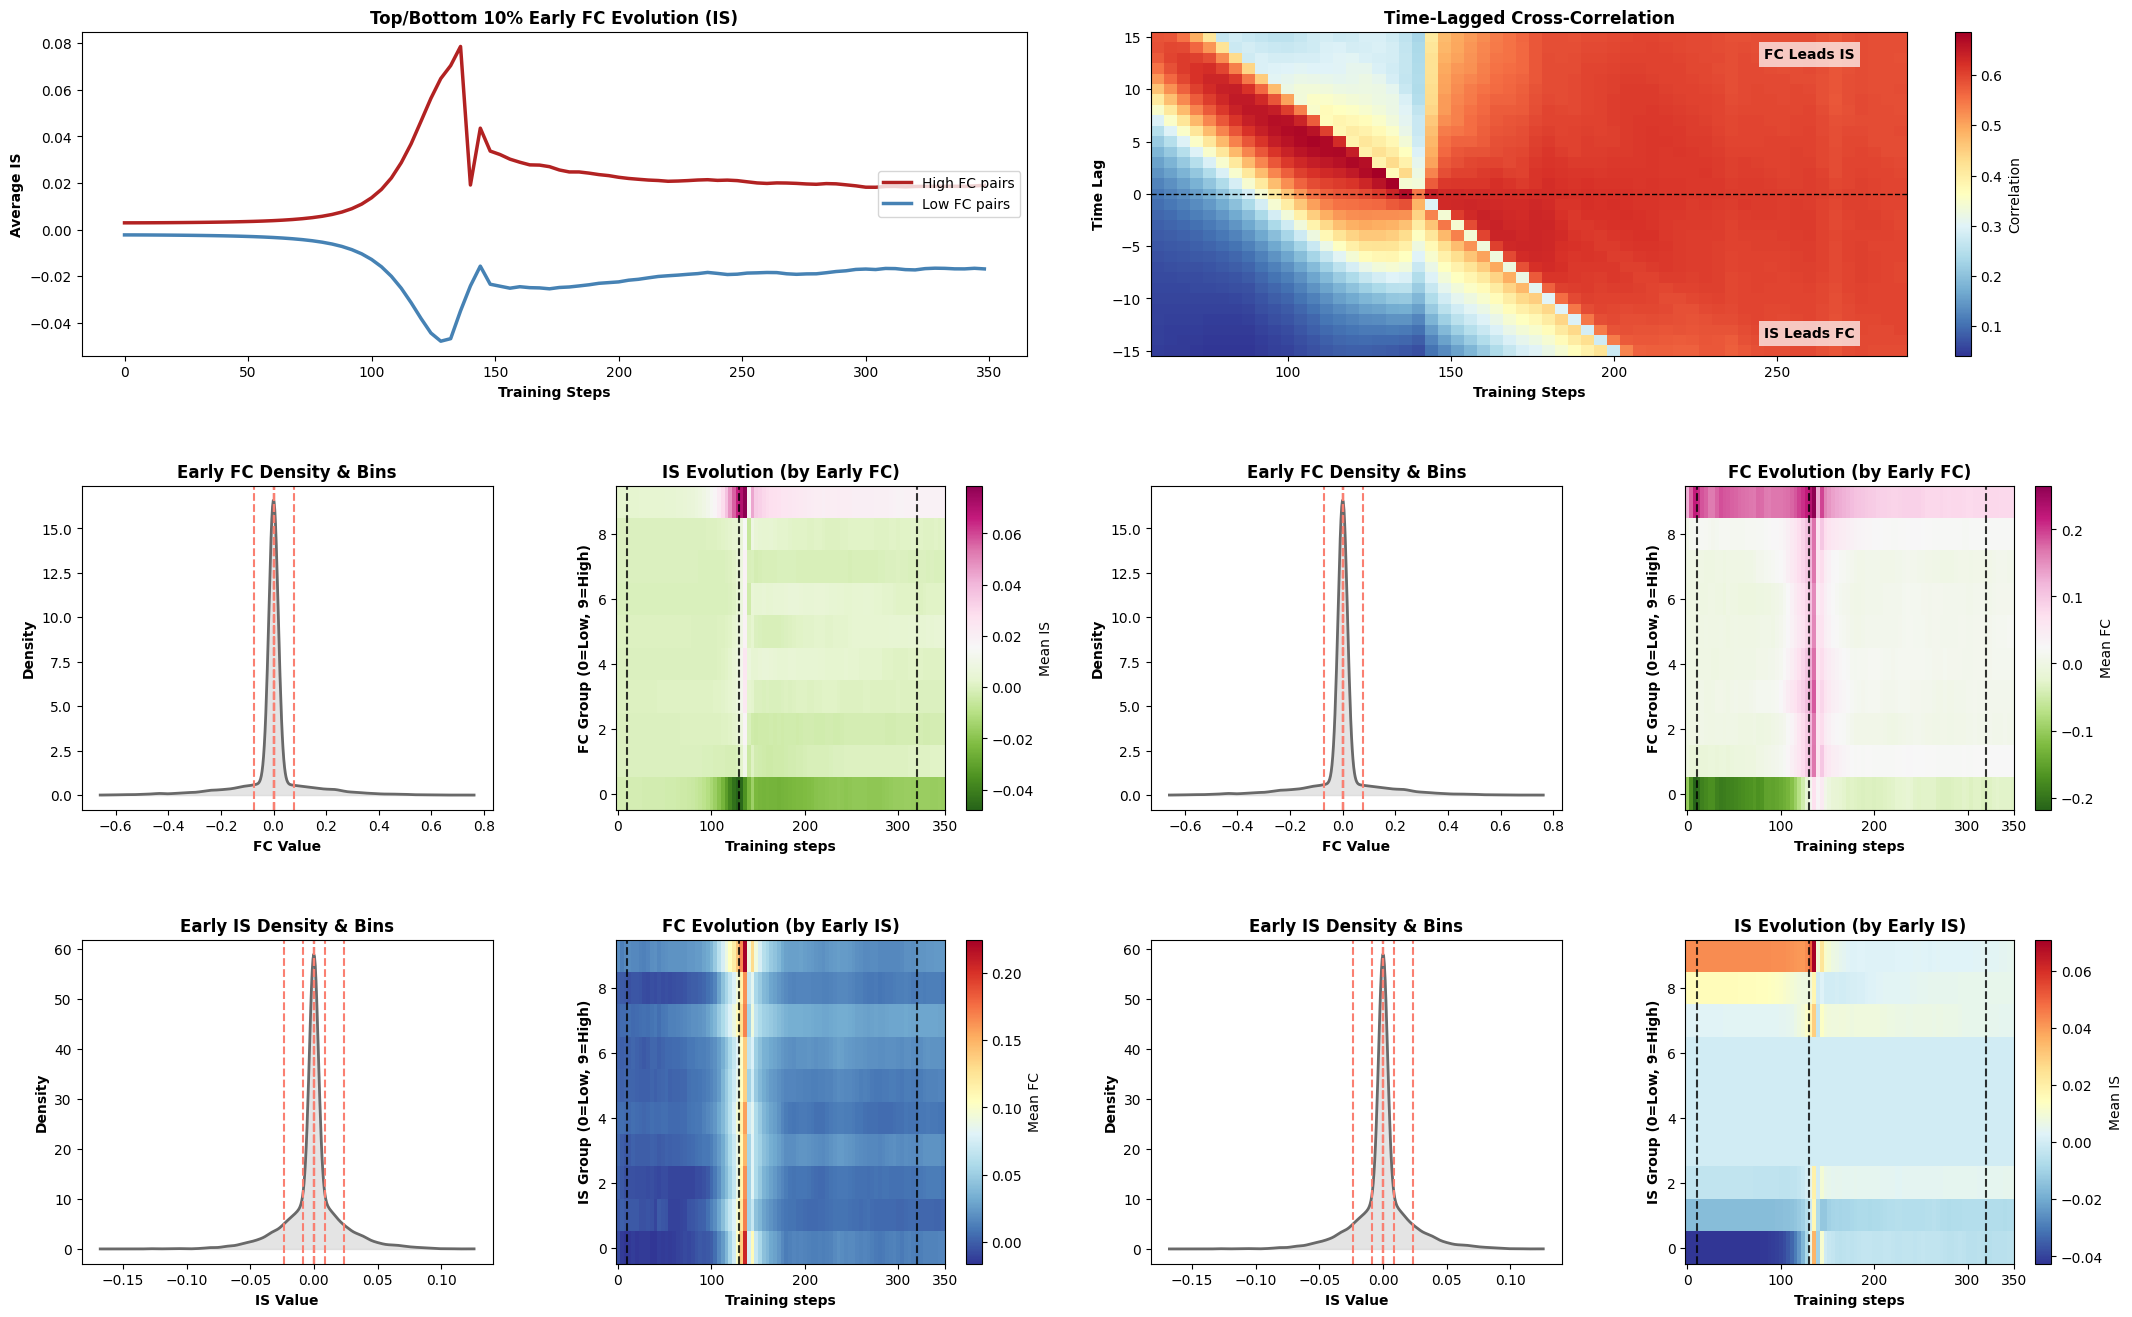

In [5]:
# 1. 运行前三个图表
analyze_macroscopic_dynamics(
    sampled_steps=sampled_steps_full, 
    fc_history=fc_hist_vecs, 
    scc_history=scc_hist_vecs,
    early_step_idx=2,
    window_size=30,
    max_lag=15,
    display_max_steps=350
)

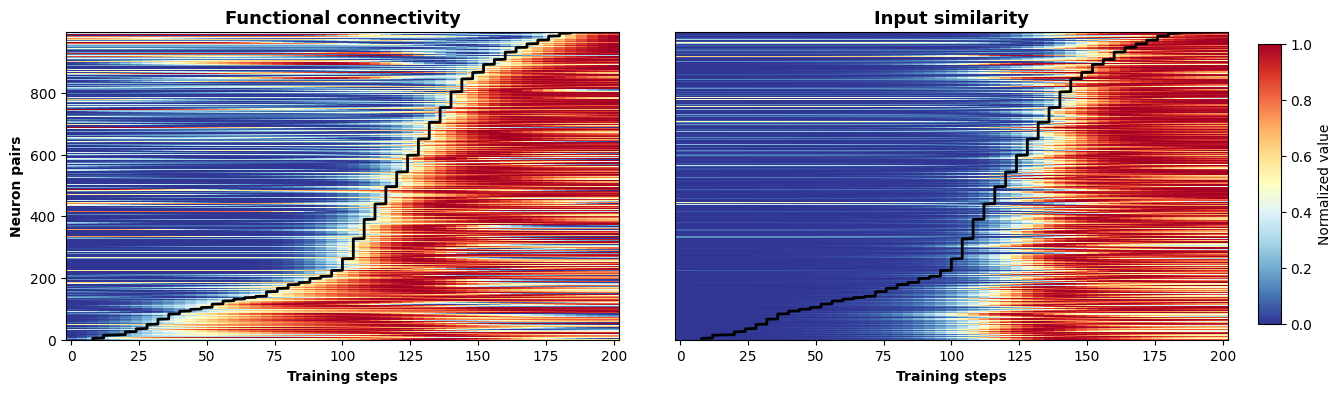

In [32]:
# 2. 运行后两个热图
analyze_gradient_alignment(
    sampled_steps=sampled_steps_full, 
    fc_history=fc_hist_vecs, 
    scc_history=scc_hist_vecs,
    early_step_idx=1,
    display_max_steps=200,
    top_k_pairs=1000
)

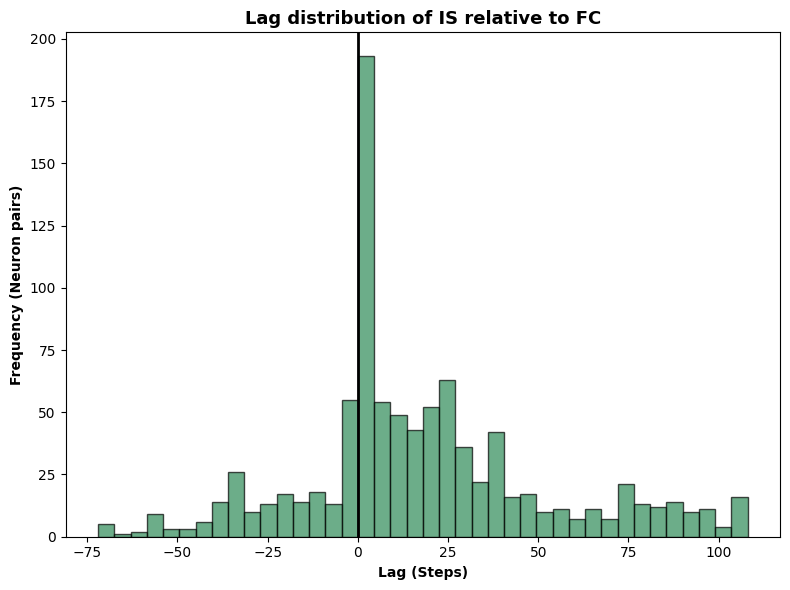

In [33]:
plot_peak_delay_distribution(
    sampled_steps_full, fc_hist_vecs, scc_hist_vecs, 
    top_k_pairs=1000, 
    fc_smooth_sigma=2.0,
    scc_smooth_sigma=2.0
)

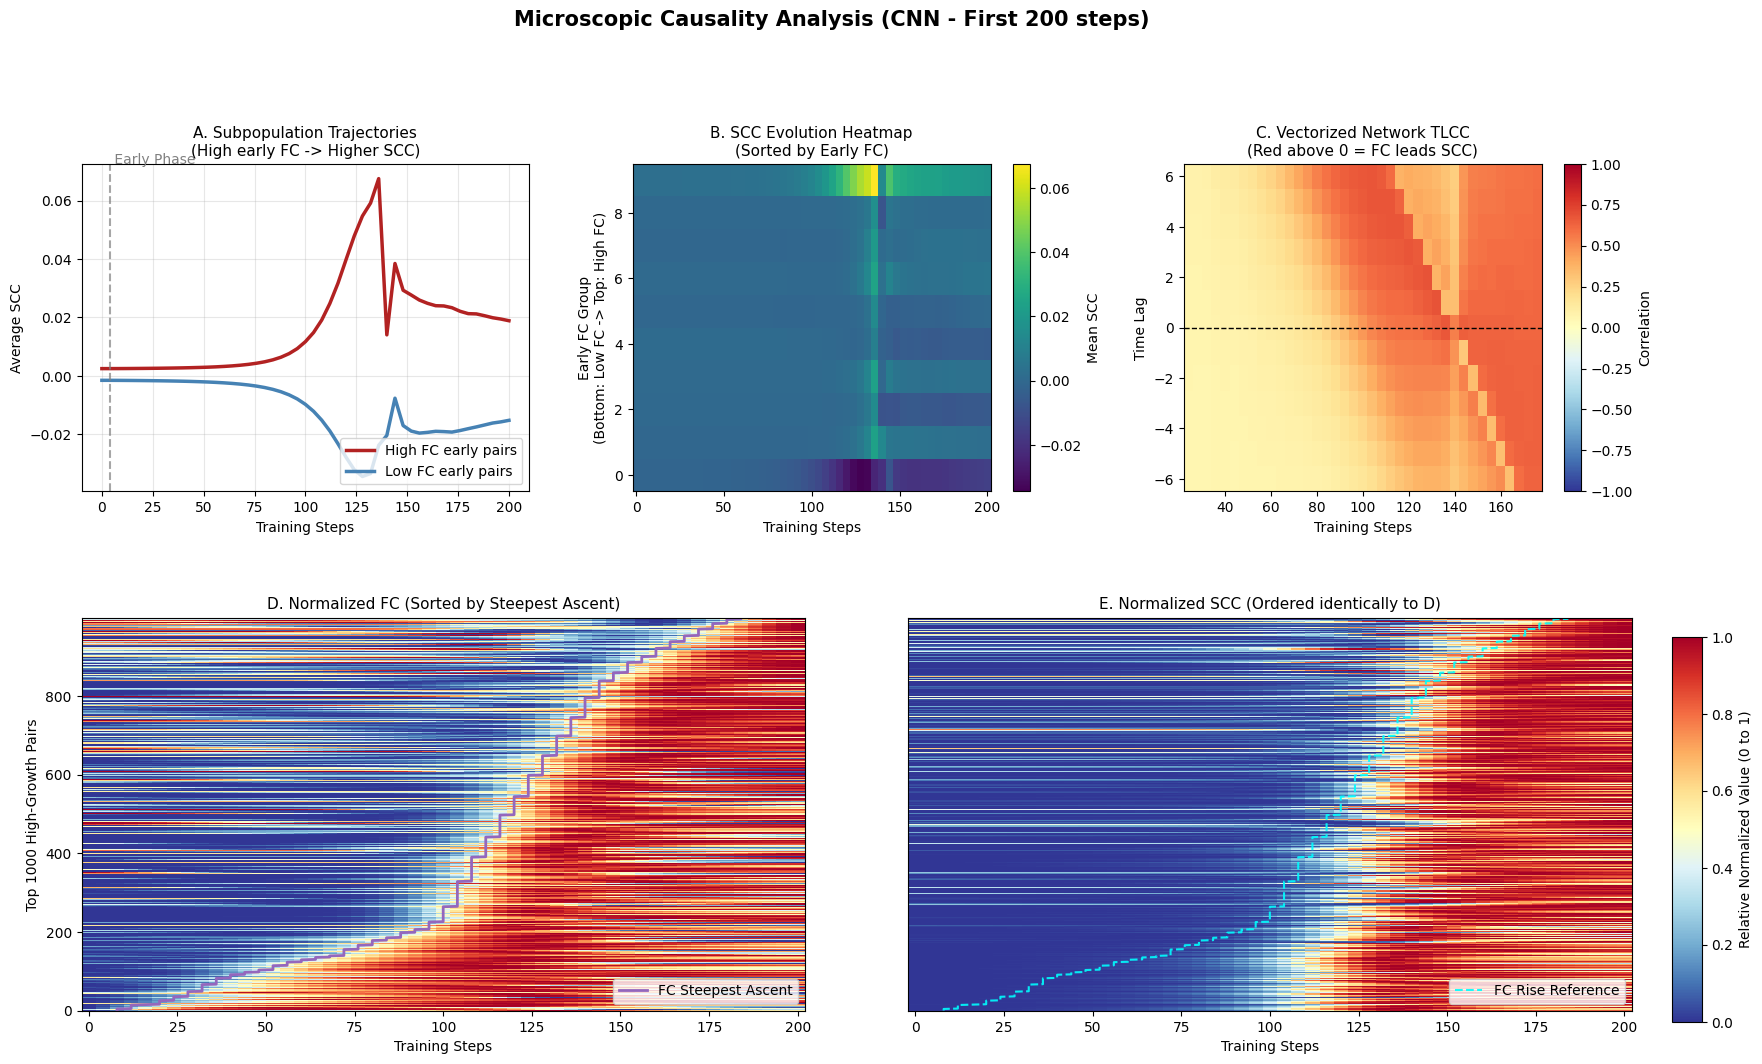

In [13]:
def analyze_pair_level_dynamics_cnn(
    sampled_steps, fc_history, scc_history, 
    early_step_idx=2,       
    window_size=10,         
    max_lag=6,              
    display_max_steps=400,  
    top_k_pairs=300         
):
    """
    微观神经元对追踪分析（5面板终极版）。
    """
    limit_idx = np.searchsorted(sampled_steps, display_max_steps, side='right')
    if limit_idx < window_size + max_lag and limit_idx != len(sampled_steps):
        print(f"[提示] display_max_steps 较小，图C可能右侧截断。")
        limit_idx = max(limit_idx, min(len(sampled_steps), window_size + 2))

    s_steps = sampled_steps[:limit_idx]
    s_fc = fc_history[:limit_idx, :]
    s_scc = scc_history[:limit_idx, :]
    N_steps, N_pairs = s_fc.shape

    fig = plt.figure(figsize=(20, 11))
    gs = gridspec.GridSpec(2, 6, height_ratios=[1, 1.2], wspace=0.6, hspace=0.35)

    # ==========================================
    # 图 A: 分组轨迹对比
    # ==========================================
    ax1 = fig.add_subplot(gs[0, 0:2])
    
    early_fc = s_fc[min(early_step_idx, N_steps-1)]
    sorted_pair_indices = np.argsort(early_fc)
    top_k = int(N_pairs * 0.1) 
    bottom_idx = sorted_pair_indices[:top_k]
    top_idx = sorted_pair_indices[-top_k:]

    ax1.plot(s_steps, np.mean(s_scc[:, top_idx], axis=1), color='firebrick', lw=2.5, label='High FC early pairs')
    ax1.plot(s_steps, np.mean(s_scc[:, bottom_idx], axis=1), color='steelblue', lw=2.5, label='Low FC early pairs')
    
    ax1.axvline(s_steps[min(early_step_idx, N_steps-1)], color='gray', linestyle='--', alpha=0.7)
    ax1.text(s_steps[min(early_step_idx, N_steps-1)], ax1.get_ylim()[1], ' Early Phase', color='gray')

    ax1.set_xlabel('Training Steps')
    ax1.set_ylabel('Average SCC')
    ax1.set_title('A. Subpopulation Trajectories\n(High early FC -> Higher SCC)', fontsize=11)
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)

    # ==========================================
    # 图 B: SCC 演化热图
    # ==========================================
    ax2 = fig.add_subplot(gs[0, 2:4])
    num_bins = 10
    bin_size = N_pairs // num_bins
    evolution_matrix = np.zeros((num_bins, N_steps))
    
    for b in range(num_bins):
        start_idx = b * bin_size
        end_idx = (b + 1) * bin_size if b < num_bins - 1 else N_pairs
        bin_indices = sorted_pair_indices[start_idx:end_idx]
        evolution_matrix[b, :] = np.mean(s_scc[:, bin_indices], axis=1)

    im2 = ax2.pcolormesh(s_steps, np.arange(num_bins), evolution_matrix, cmap='viridis', shading='auto')
    ax2.set_xlabel('Training Steps')
    ax2.set_ylabel('Early FC Group\n(Bottom: Low FC -> Top: High FC)')
    ax2.set_title('B. SCC Evolution Heatmap\n(Sorted by Early FC)', fontsize=11)
    fig.colorbar(im2, ax=ax2, label='Mean SCC')

    # ==========================================
    # 图 C: 向量级滑动交叉相关 (TLCC)
    # ==========================================
    ax3 = fig.add_subplot(gs[0, 4:6])
    half_w = window_size // 2
    tlcc_matrix = []
    center_steps = []

    for i in range(half_w, N_steps - half_w):
        corrs = []
        for lag in range(-max_lag, max_lag + 1):
            if lag == 0:
                c = np.corrcoef(s_fc[i].flatten(), s_scc[i].flatten())[0, 1]
            elif lag > 0 and i+lag < N_steps:
                c = np.corrcoef(s_fc[i].flatten(), s_scc[i+lag].flatten())[0, 1]
            elif lag < 0 and i-abs(lag) >= 0:
                c = np.corrcoef(s_fc[i].flatten(), s_scc[i-abs(lag)].flatten())[0, 1]
            else:
                c = np.nan
            corrs.append(c if not np.isnan(c) else 0)
        tlcc_matrix.append(corrs)
        center_steps.append(s_steps[i])

    if tlcc_matrix:
        tlcc_matrix = np.array(tlcc_matrix).T
        lags = np.arange(-max_lag, max_lag + 1)
        im3 = ax3.pcolormesh(center_steps, lags, tlcc_matrix, shading='auto', cmap='RdYlBu_r', vmin=-1, vmax=1)
        ax3.axhline(0, color='black', lw=1, ls='--')
        ax3.set_xlabel("Training Steps")
        ax3.set_ylabel("Time Lag")
        ax3.set_title("C. Vectorized Network TLCC\n(Red above 0 = FC leads SCC)", fontsize=11)
        fig.colorbar(im3, ax=ax3, label="Correlation")

    # ==========================================
    # 图 D & E: 梯度正峰值对齐热图
    # ==========================================
    early_scc_baseline = np.mean(s_scc[:min(early_step_idx + 1, N_steps), :], axis=0)
    scc_growth_trend = np.mean(s_scc[-max(1, N_steps//10):, :], axis=0) - early_scc_baseline
    
    # 挑选 SCC 净增长最多的神经元对展现演化趋势
    filtered_active_idx = np.argsort(scc_growth_trend)[-top_k_pairs:]
    
    fc_active = s_fc[:, filtered_active_idx].T 
    scc_active = s_scc[:, filtered_active_idx].T

    smooth_sigma = 3.0  
    fc_smooth = gaussian_filter1d(fc_active, sigma=smooth_sigma, axis=1)
    scc_smooth = gaussian_filter1d(scc_active, sigma=smooth_sigma, axis=1)

    fc_norm = (fc_smooth - fc_smooth.min(axis=1, keepdims=True)) / \
              (fc_smooth.max(axis=1, keepdims=True) - fc_smooth.min(axis=1, keepdims=True) + 1e-8)
    scc_norm = (scc_smooth - scc_smooth.min(axis=1, keepdims=True)) / \
               (scc_smooth.max(axis=1, keepdims=True) - scc_smooth.min(axis=1, keepdims=True) + 1e-8)

    fc_gradient = np.diff(fc_norm, axis=1)
    rapid_rise_indices = np.argmax(fc_gradient, axis=1)
    
    sort_order = np.argsort(rapid_rise_indices)
    
    fc_sorted = fc_norm[sort_order]
    scc_sorted = scc_norm[sort_order]
    grad_peaks_sorted = rapid_rise_indices[sort_order]

    ax4 = fig.add_subplot(gs[1, 0:3])
    im4 = ax4.pcolormesh(s_steps, np.arange(top_k_pairs), fc_sorted, cmap='RdYlBu_r', shading='auto', vmin=0, vmax=1)
    ax4.plot(s_steps[grad_peaks_sorted], np.arange(top_k_pairs), color='tab:purple', lw=2, alpha=1, label='FC Steepest Ascent')
    ax4.set_xlabel("Training Steps")
    ax4.set_ylabel(f"Top {top_k_pairs} High-Growth Pairs")
    ax4.set_title("D. Normalized FC (Sorted by Steepest Ascent)", fontsize=11)
    ax4.legend(loc="lower right")

    ax5 = fig.add_subplot(gs[1, 3:6])
    im5 = ax5.pcolormesh(s_steps, np.arange(top_k_pairs), scc_sorted, cmap='RdYlBu_r', shading='auto', vmin=0, vmax=1)
    ax5.plot(s_steps[grad_peaks_sorted], np.arange(top_k_pairs), color='cyan', lw=1.5, ls='--', alpha=0.9, label='FC Rise Reference')
    ax5.set_xlabel("Training Steps")
    ax5.set_yticks([]) 
    ax5.set_title("E. Normalized SCC (Ordered identically to D)", fontsize=11)
    ax5.legend(loc="lower right")

    cbar_ax = fig.add_axes([0.92, 0.1, 0.015, 0.35]) 
    fig.colorbar(im4, cax=cbar_ax, label="Relative Normalized Value (0 to 1)")

    plt.suptitle(f"Microscopic Causality Analysis (CNN - First {display_max_steps} steps)", fontsize=15, fontweight='bold', y=1.02)
    plt.show()

    
# 5. [新增] 提取微观数据 (约需几十秒到一两分钟)
# 注意 step_interval 的设置。如果你跑了 2 个 epoch (约 400 个 batch)
# 设为 5 代表共提取 80 个快照；设为 2 代表提取 200 个快照。


# 6. [新增] 运行微观神经元对追踪分析
analyze_pair_level_dynamics_cnn(
    sampled_steps=sampled_steps_full, 
    fc_history=fc_hist_vecs, 
    scc_history=scc_hist_vecs,
    early_step_idx=1,       # 第 2 个采样点作为早期定义基准
    window_size=12,         # 滑动窗口
    max_lag=6,              # 最大相关滞后
    display_max_steps=200,  # X 轴显示最大范围
    top_k_pairs=1000         # 下方 D/E 图展示净增长最大的前 300 对
)

准备数据并加载 Step 469 的模型状态...
正在执行层次聚类计算 (可能需要几秒钟)...
正在生成可视化图表...


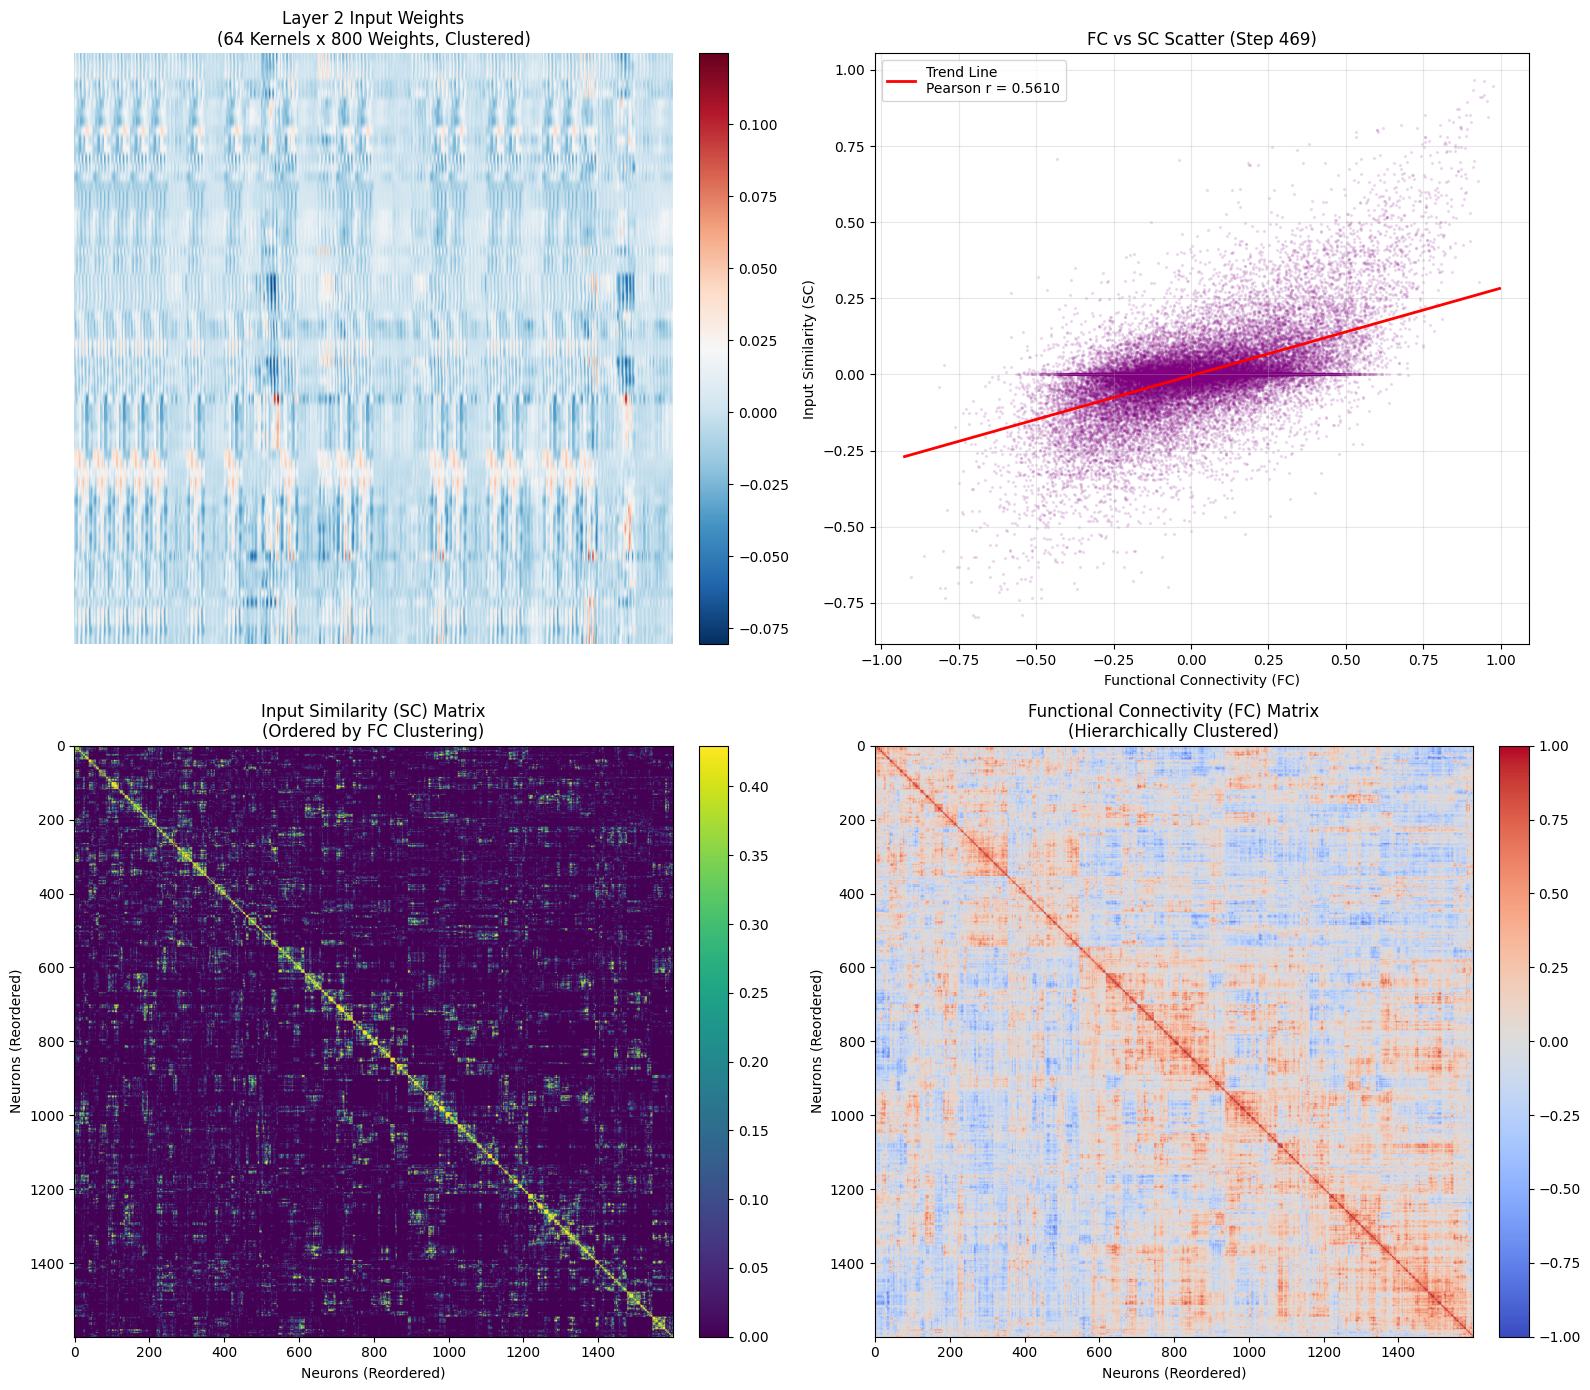

In [5]:
import scipy.cluster.hierarchy as sch
import scipy.spatial.distance as dist
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np
import torch

def analyze_single_step_state(models, train_loader, in_channels, act='relu', step_idx=0, max_scatter_samples=50000):
    """
    提取指定 Step 的模型状态，绘制:
    1. Layer 2 输入权重的聚类热图
    2. SC vs FC 散点图及相关性
    3. 功能连接 (FC) 聚类热图
    4. 输入权重相似性 (SC) 热图 (严格按照 FC 的聚类顺序排列)
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    template_model = SimpleCNN(in_channels=in_channels, activation=act).to(device)
    layer_shapes = template_model.get_layer_shapes()
    
    n_neurons = layer_shapes['conv2'][0] * layer_shapes['conv2'][1] * layer_shapes['conv2'][2] # 1600
    
    print(f"准备数据并加载 Step {step_idx} 的模型状态...")
    subset_data = get_fixed_subset(train_loader, samples_per_class=30)
    template_model.load_state_dict(models[step_idx])
    template_model.eval()

    # --- 1. 获取基础数据 ---
    # 1.1 获取并处理输入权重 (64 个输出通道, 每个通道 32*5*5=800 个权重)
    raw_weights = template_model.conv2.weight.data.view(64, -1).cpu().numpy()
    
    # 1.2 获取 SC 矩阵 (1600 x 1600)
    sc_matrix = get_cnn_input_similarity(template_model, layer_shapes, device)
    
    # 1.3 获取 FC 矩阵 (1600 x 1600)
    fc_matrix = get_cnn_functional_connectivity(template_model, subset_data, device)

    # --- 2. 聚类计算 ---
    print("正在执行层次聚类计算 (可能需要几秒钟)...")
    
    # 2.1 对输入权重独立聚类 (基于欧氏距离)
    linkage_w = sch.linkage(raw_weights, method='ward', metric='euclidean')
    order_w = sch.leaves_list(linkage_w)
    weights_reordered = raw_weights[order_w, :]

    # 2.2 对功能连接 (FC) 进行聚类
    # 使用 1 - 相关系数 作为距离度量，避免负数干扰
    fc_distance = np.clip(1.0 - fc_matrix, 0.0, 2.0)
    # 将冗余的对称矩阵压缩为一维距离向量，这是 scipy 聚类的标准输入格式
    condensed_fc_dist = dist.squareform(fc_distance, checks=False) 
    linkage_fc = sch.linkage(condensed_fc_dist, method='ward')
    order_fc = sch.leaves_list(linkage_fc)

    # 2.3 按照 FC 的聚类顺序，同时重排 FC 和 SC 矩阵
    fc_reordered = fc_matrix[order_fc, :][:, order_fc]
    sc_reordered = sc_matrix[order_fc, :][:, order_fc]

    # --- 3. 散点图数据计算 ---
    triu_idx = np.triu_indices(n_neurons, k=1)
    fc_triu = fc_matrix[triu_idx]
    sc_triu = sc_matrix[triu_idx]
    
    valid_mask = np.isfinite(fc_triu) & np.isfinite(sc_triu)
    fc_clean = fc_triu[valid_mask]
    sc_clean = sc_triu[valid_mask]
    
    pearson_corr, p_val = stats.pearsonr(fc_clean, sc_clean)
    
    # 降采样以加速散点图绘制
    if len(fc_clean) > max_scatter_samples:
        sample_indices = np.random.choice(len(fc_clean), max_scatter_samples, replace=False)
        plot_fc = fc_clean[sample_indices]
        plot_sc = sc_clean[sample_indices]
    else:
        plot_fc, plot_sc = fc_clean, sc_clean

    # --- 4. 绘图 ---
    print("正在生成可视化图表...")
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    
    # 子图 1: 输入权重热图 (独立聚类)
    # im1 = axes[0, 0].imshow(weights_reordered, aspect='auto', cmap='RdBu_r')
    # axes[0, 0].set_title('Layer 2 Input Weights\n(64 Kernels x 800 Weights, Clustered)', fontsize=12)
    # axes[0, 0].set_ylabel('Kernels (Reordered)')
    # axes[0, 0].set_xlabel('Flattened Kernel Weights')
    # fig.colorbar(im1, ax=axes[0, 0], fraction=0.046, pad=0.04)
    # vmin = np.percentile(weights_reordered, 1)
    # vmax = np.percentile(weights_reordered, 99)
    # 若想对称（推荐用于 RdBu_r）：
    # limit = np.percentile(np.abs(weights_reordered), 98)
    # vmin, vmax = -limit, limit

    im1 = axes[0, 0].imshow(
        weights_reordered,
        aspect='auto',
        cmap='RdBu_r',
        # vmin=vmin,
        # vmax=vmax
    )

    axes[0, 0].set_title('Layer 2 Input Weights\n(64 Kernels x 800 Weights, Clustered)', fontsize=12)

    # 去掉边框
    axes[0, 0].set_frame_on(False)

    # 去掉刻度
    axes[0, 0].set_xticks([])
    axes[0, 0].set_yticks([])

    # 去掉轴标签（直接不写，或设置为空）
    axes[0, 0].set_xlabel('')
    axes[0, 0].set_ylabel('')

    # colorbar 保持原样
    fig.colorbar(im1, ax=axes[0, 0], fraction=0.046, pad=0.04)

    # 子图 2: SC vs FC 散点图
    axes[0, 1].scatter(plot_fc, plot_sc, alpha=0.1, s=2, color='purple')
    m, b = np.polyfit(fc_clean, sc_clean, 1)
    x_line = np.linspace(np.min(fc_clean), np.max(fc_clean), 100)
    axes[0, 1].plot(x_line, m * x_line + b, color='red', linewidth=2, 
                    label=f'Trend Line\nPearson r = {pearson_corr:.4f}')
    axes[0, 1].set_title(f'FC vs SC Scatter (Step {step_idx})', fontsize=12)
    axes[0, 1].set_xlabel('Functional Connectivity (FC)')
    axes[0, 1].set_ylabel('Input Similarity (SC)')
    axes[0, 1].legend(loc='upper left')
    axes[0, 1].grid(True, alpha=0.3)

    # 子图 3: SC 热图 (按 FC 顺序排列)
    # 使用 vmin 和 vmax 固定颜色范围，使对比更明显
    im3 = axes[1, 0].imshow(sc_reordered, aspect='auto', cmap='viridis', vmin=0, vmax=np.percentile(sc_reordered, 99))
    axes[1, 0].set_title('Input Similarity (SC) Matrix\n(Ordered by FC Clustering)', fontsize=12)
    axes[1, 0].set_xlabel('Neurons (Reordered)')
    axes[1, 0].set_ylabel('Neurons (Reordered)')
    fig.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04)

    # 子图 4: FC 热图 (按 FC 顺序排列)
    im4 = axes[1, 1].imshow(fc_reordered, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
    axes[1, 1].set_title('Functional Connectivity (FC) Matrix\n(Hierarchically Clustered)', fontsize=12)
    axes[1, 1].set_xlabel('Neurons (Reordered)')
    axes[1, 1].set_ylabel('Neurons (Reordered)')
    fig.colorbar(im4, ax=axes[1, 1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    return fc_matrix, sc_matrix, fc_clean, sc_clean

# ==================== 使用示例 ====================
# 查看网络训练到后期（比如最后一个保存的状态）的空间拓扑结构
fc_raw, sc_raw, fc_clean, sc_clean = analyze_single_step_state(model_states, train_loader, in_channels=in_channels, act=ACTIVATION, step_idx=len(model_states)-1)

In [6]:
np.save('/mnt/Data16T/Data/haichao/code/Continuous Discrete/story/story_part2_struc_func/struc_func_matrix_save/CNN/FC_1600neuron.npy', fc_raw)
np.save('/mnt/Data16T/Data/haichao/code/Continuous Discrete/story/story_part2_struc_func/struc_func_matrix_save/CNN/IS_1600neuron.npy', sc_raw)

In [4]:
sc_clean.shape

(1279200,)